# EDA

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [81]:
## Load metadata
df = pd.read_csv("../data/metadata - standardized.csv")
df.head()

,names,types,type_expanded,isColor,original_name,patient_id,fundus,fundus_od_seg,fundus_oc_seg,bv_seg,...,cdr_expert4,refractive_dioptre_1,refractive_dioptre_2,refractive_astigmatism,phakic_or_pseudophakic,iop_perkins,iop_pneumatic,pachymetry,axial_length,visual_field_mean_defect
0,OIA-ODIR-TEST-OFFLINE-1,0,NaN,1,1029_right.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-1.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OIA-ODIR-TEST-OFFLINE-2,0,NaN,1,1049_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-2.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OIA-ODIR-TEST-OFFLINE-4,0,NaN,1,1128_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-4.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OIA-ODIR-TEST-OFFLINE-5,0,NaN,1,1179_right.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-5.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OIA-ODIR-TEST-OFFLINE-6,0,NaN,1,1180_left.jpg,NaN,/full-fundus/OIA-ODIR-TEST-OFFLINE-6.png,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### There are 12,316 total samples and 48 columns/features. 
| Column        | Meaning                   |
| ------------- | ------------------------- |
| fundus        | Path to fundus image      |
| fundus_od_seg | Optic disc segmentation   |
| fundus_oc_seg | Optic cup segmentation    |
| bv_seg        | Blood vessel segmentation |
| artery_seg    | Artery segmentation       |
| vein_seg      | Vein segmentation         |
| oct           | OCT image                 |
| oct_oc_seg    | OCT cup segmentation      |
| oct_od_seg    | OCT disc segmentation     |


In [82]:
## dataset shape
print("Total samples:", len(df))
df.info()


Total samples: 12449
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   names                     12449 non-null  object 
 1   types                     12449 non-null  int64  
 2   type_expanded             6577 non-null   object 
 3   isColor                   12449 non-null  int64  
 4   original_name             12449 non-null  object 
 5   patient_id                488 non-null    object 
 6   fundus                    12449 non-null  object 
 7   fundus_od_seg             3103 non-null   object 
 8   fundus_oc_seg             3103 non-null   object 
 9   bv_seg                    462 non-null    object 
 10  artery_seg                22 non-null     object 
 11  vein_seg                  22 non-null     object 
 12  oct                       79 non-null     object 
 13  oct_oc_seg                45 non-null   

In [83]:
df['types'].unique()

array([ 0,  1, -1])

-1 → Suspected

0 → Normal

1 → Glaucoma

### Cleaning the Dataset

In [84]:
## Removing class suspected to perform binary classification to avoid ambiguity.
df = df[df['types'] != -1]

In [85]:
## Checking missing values
df.isnull().sum()

names                           0
types                           0
type_expanded                5807
isColor                         0
original_name                   0
patient_id                  11896
fundus                          0
fundus_od_seg                9281
fundus_oc_seg                9281
bv_seg                      11854
artery_seg                  12294
vein_seg                    12294
oct                         12237
oct_oc_seg                  12271
oct_od_seg                  12271
sex                          7852
gender                      11896
age                          7432
eye                          6703
sbp                         12294
dbp                         12294
hr                          12294
iop                         12294
vcdr                        11666
Unnamed: 24                 12316
notchI_present              12215
notchS_present              12215
notchN_present              12215
notchT_present              12215
expert1_grade 

From the above analysis, Core Columns such as names, types, isColor, original_name, fundus have 0 nulls, which means that:
* Every sample has a fundus image
* Every sample has a label
* Dataset is complete for classification

Furthermore, \
fundus_od_seg → 9281 null \
fundus_oc_seg → 9281 null \
Only ~3035 images have segmentation masks. \

bv_seg → 11854 null \
Only 462 images have vessel masks. \
oct → 12237 null \
Only 79 images have OCT. \

So this dataset contains:

Mostly fundus images

Few OCT samples

We are only using fundus images.

### Class Distribution Analysis

In [86]:
df['types'].value_counts()

types
0    7549
1    4767
Name: count, dtype: int64

In [87]:
(df['types'].value_counts(normalize=True) * 100)

types
0    61.294251
1    38.705749
Name: proportion, dtype: float64

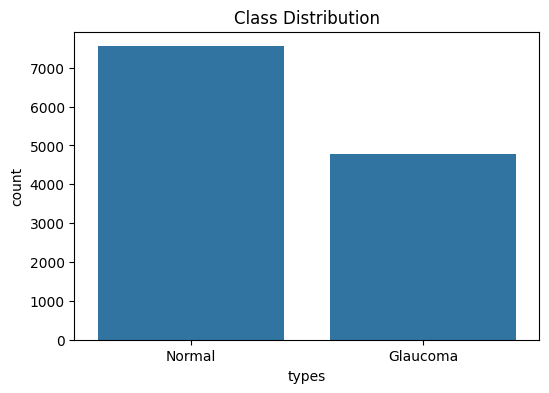

In [88]:
plt.figure(figsize=(6,4))
sns.countplot(x='types', data=df)
plt.title("Class Distribution")
plt.xticks([0,1], ["Normal", "Glaucoma"])
plt.show()

#### The figure clearly shows class imbalance. So balancing is needed further.

### Image Path Construction

In [89]:
import os

print(os.listdir("../data/full-fundus/full-fundus")[:10])

['EyePACS-Glaucoma-2520.png', 'EyePACS-Glaucoma-2659.png', 'OIA-ODIR-TEST-OFFLINE-423.png', 'REFUGE1-train-343.png', 'OIA-ODIR-TRAIN-2788.png', 'EyePACS-Glaucoma-107.png', 'OIA-ODIR-TRAIN-14.png', 'BEH-634.png', 'OIA-ODIR-TRAIN-2615.png', 'EyePACS-Glaucoma-1579.png']


In [90]:
BASE_DIR = "../data/full-fundus/full-fundus"

df['path'] = df['names'].apply(
    lambda x: os.path.join(BASE_DIR, x + ".png")
)


In [91]:
print(df["path"].iloc[0])
print(os.path.exists(df['path'].iloc[0]))

../data/full-fundus/full-fundus/OIA-ODIR-TEST-OFFLINE-1.png
True


### Image Resolution Analysis

In [92]:
heights = []
widths = []

for path in df['path'].sample(500):
    img = cv2.imread(path)
    h, w, _ = img.shape
    heights.append(h)
    widths.append(w)

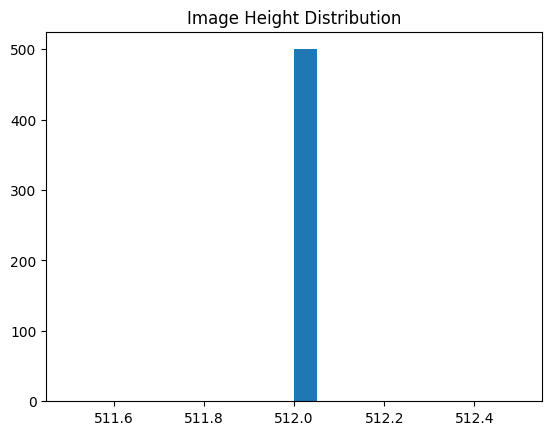

In [93]:
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()


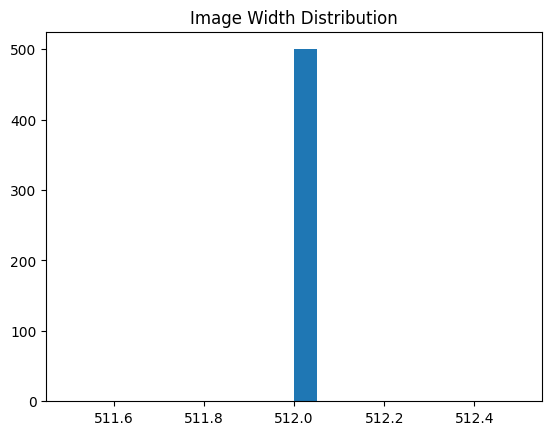

In [94]:
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

### Visual Inspection of Images

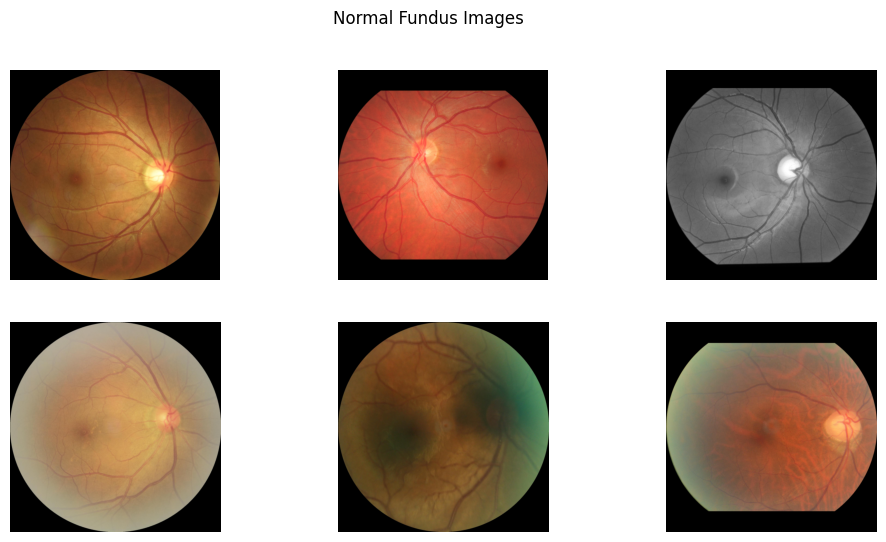

In [95]:
normal_imgs = df[df['types'] == 0]['path'].sample(6)

plt.figure(figsize=(12,6))
for i, path in enumerate(normal_imgs):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Normal Fundus Images")
plt.show()

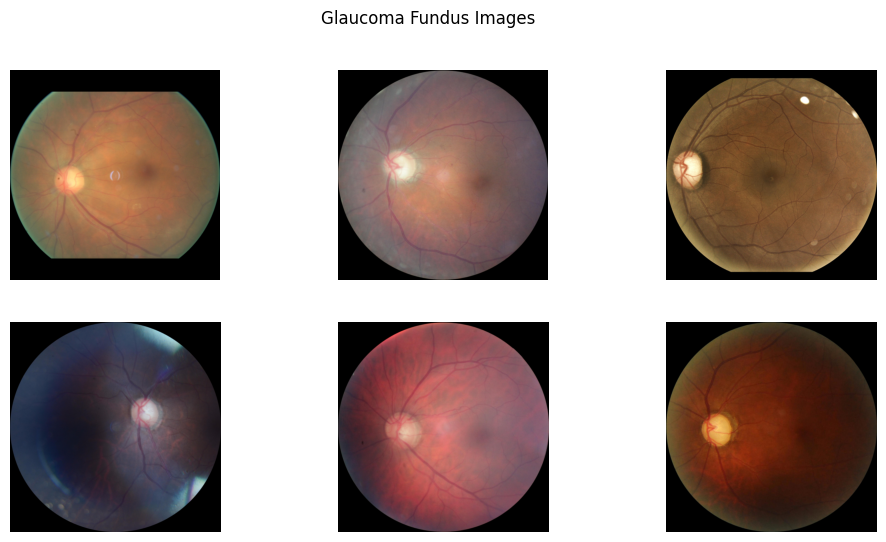

In [96]:
normal_imgs = df[df['types'] == 1]['path'].sample(6)

plt.figure(figsize=(12,6))
for i, path in enumerate(normal_imgs):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Glaucoma Fundus Images")
plt.show()

### Pixel Intensity Distribution

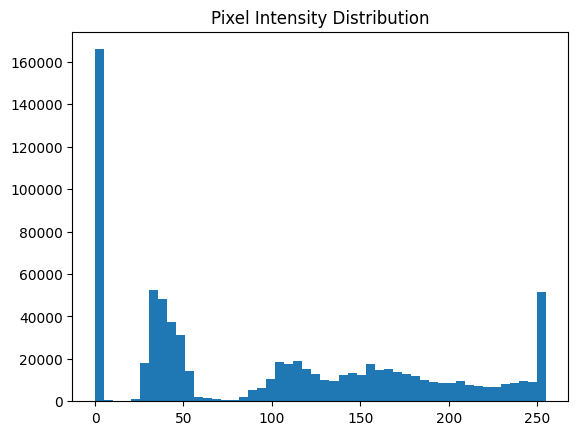

In [97]:
## flatten pixels
sample_img = cv2.imread(df['path'].iloc[0])
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

plt.hist(sample_img.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

### Train / Val / Test Split Analysis

In [98]:
image_directory = r'..\data\full-fundus\full-fundus'
image_size = 256
seed = 24
batch_size = 32

def get_path(name):
    return image_directory + '\\' + name + '.png'

df['path'] = df['names'].apply(get_path)
df.drop('names', axis=1, inplace=True)

In [99]:
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(df, test_size=0.2, random_state=seed)
train_data, test_data = train_test_split(train_data, test_size=0.1, random_state=seed)

In [100]:
print("Train:", train_data['types'].value_counts())
print("Val:", val_data['types'].value_counts())
print("Test:", test_data['types'].value_counts())

Train: types
0    5433
1    3433
Name: count, dtype: int64
Val: types
0    1527
1     937
Name: count, dtype: int64
Test: types
0    589
1    397
Name: count, dtype: int64


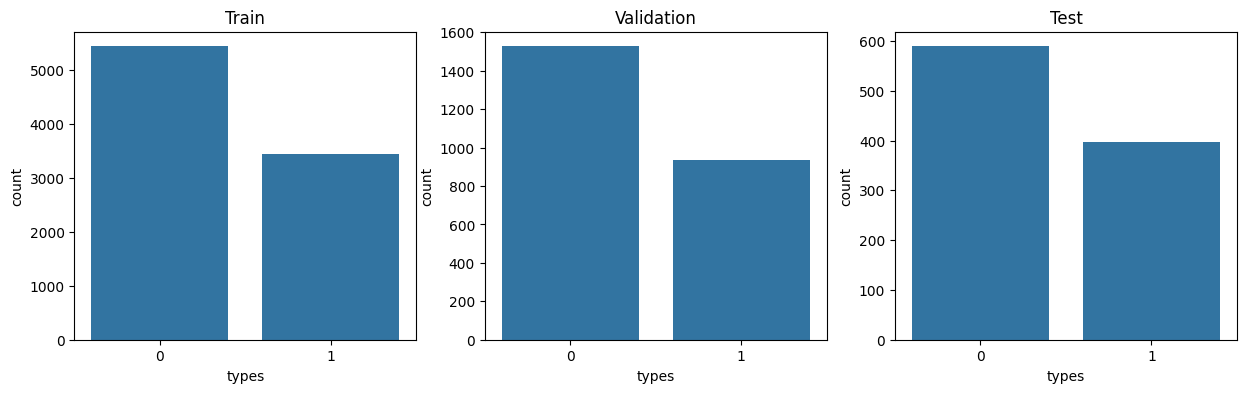

In [101]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.countplot(x='types', data=train_data, ax=axes[0])
axes[0].set_title("Train")

sns.countplot(x='types', data=val_data, ax=axes[1])
axes[1].set_title("Validation")

sns.countplot(x='types', data=test_data, ax=axes[2])
axes[2].set_title("Test")

plt.show()

### Data Augmentation Visualization

In [ ]:
import cv2
img = cv2.imread(train_data['path'].iloc[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img / 255.0

plt.figure(figsize=(12,6))
for i in range(6):
    aug_img = train_dataset.__augment__(img)
    plt.subplot(2,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
plt.suptitle("Augmented Samples")
plt.show()
